In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

Creating another similarity analysis with micronutrient information

In [2]:
fineli_data = pd.read_csv("../Datasets/fineli.csv", sep=";")
fineli_data = fineli_data[[ "name",
                            "energia, laskennallinen (kJ)",
                            "rasva (g)",
                            "hiilihydraatti imeytyvä (g)",
                            "proteiini (g)",

                            "kalsium (mg)",
                            "rauta (mg)",
                            "kalium (mg)",
                            "magnesium (mg)",
                            "natrium (mg)",
                            "fosfori (mg)",

                            "A-vitamiini RAE (µg)",
                            "B12-vitamiini (kobalamiini) (µg)",
                            "C-vitamiini (mg)",
                            "D-vitamiini (µg)",
                            "E-vitamiini alfatokoferoli (mg)"
                        ]]

fineli_data.head()

,name,"energia, laskennallinen (kJ)",rasva (g),hiilihydraatti imeytyvä (g),proteiini (g),kalsium (mg),rauta (mg),kalium (mg),magnesium (mg),natrium (mg),fosfori (mg),A-vitamiini RAE (µg),B12-vitamiini (kobalamiini) (µg),C-vitamiini (mg),D-vitamiini (µg),E-vitamiini alfatokoferoli (mg)
0,Ahven,345,0.7,0,18.8,109.0,0.3,330.0,26.0,45.6,240.0,6.4,1.9,0,15.2,1.5
1,"Ahven, leivitetty, paistettu",660,6.5,4.7,19.9,114.2,0.4,347.3,28.7,307.5,253.6,28.0,1.6,<0.1,15.8,2.5
2,"Ahven, paistettu, ei korppujauhoja",600,6.8,<0.1,20.5,120.6,0.3,360.4,28.7,328.1,263.0,29.9,1.8,<0.1,16.8,2.7
3,"Ahven, paistettu voissa, ei korppujauhoja",595,7.3,<0.1,19.1,113.6,0.3,335.2,26.8,484.8,245.9,62.9,1.6,0,15.3,1.6
4,"Ahvenet foliossa, voissa",496,4.1,0.6,19.5,120.6,0.4,377.2,29.0,467.8,254.0,40.2,1.6,1.7,15.5,1.6


In [3]:
CQP_1 = pd.read_csv("../Datasets/CQP1.csv", sep=";")
CQP_2 = pd.read_csv("../Datasets/CQP2.csv", sep=";")
CQP_3 = pd.read_csv("../Datasets/CQP3.csv", sep=";")
CQP_4 = pd.read_csv("../Datasets/CQP4.csv", sep=";")
CQP_5 = pd.read_csv("../Datasets/CQP5.csv", sep=";")
CQP_6 = pd.read_csv("../Datasets/CQP6.csv", sep=";")
CQP_7 = pd.read_csv("../Datasets/CQP7.csv", sep=";")
CQP_8 = pd.read_csv("../Datasets/CQP8.csv", sep=";")

CQP = pd.concat([CQP_1, CQP_2, CQP_3, CQP_4, CQP_5, CQP_6, CQP_7, CQP_8])
CQP = CQP[["word", "text_thread_id"]]

CQP.head()

,word,text_thread_id
0,Σ,Σ
1,hapankaali,16796146
2,hedelmä,17969829
3,hampurilainen,18191211
4,hedelmä,17254127


Removing duplicates

In [4]:
food_filter = CQP["word"].dropna().str.lower().drop_duplicates().tolist()
food_filter.remove('σ')

print(food_filter)
print(len(food_filter))

['hapankaali', 'hedelmä', 'hampurilainen', 'ananas', 'banaani', 'ahven', 'hauki', 'hernekeitto', 'bataatti', 'chili', 'broileri', 'hillo', 'herne', 'appelsiini', 'hiiva', 'anjovis', 'avokado', 'ateriankorvike', 'etana', 'hunaja', 'hummeri', 'ahvenet', 'hoki', 'borssikeitto', 'hirssi', 'herkkusieni', 'haaparousku', 'grillimakkara', 'creme', 'basilika', 'auringonkukansiemen', 'aromisuola', 'hirvenliha', 'donitsi', 'blini', 'ankerias', 'herkkutatti', 'granaattiomena', 'graavilohi', 'fruktoosi', 'etikkakurkku', 'energiajuoma', 'elovena', 'chiansiemen', 'broilerikeitto', 'broilerifilee', 'aprikoosi', 'hummus', 'herkkusienikeitto', 'booli', 'amarantti', 'hedelmäsalaatti', 'greippi', 'hirvenpaisti', 'hillosipulisäilyke', 'herneenverso', 'heraproteiinikonsentraatti', 'herajauhe', 'hedelmäjuoma', 'hedelmähillo', 'hasselpähkinäjuoma', 'hapanlohko', 'hapankurkku', 'hapankorppu', 'hapankaalikeitto', 'hampunsiemen', 'guava', 'fenkolikeitto', 'fenkoli', 'etikkasienisäilyke', 'etikkapunajuuri', 'erik

Standardization

In [5]:
from sklearn.preprocessing import StandardScaler

fineli_data["name"] = fineli_data["name"].str.lower()

filtered_df = fineli_data[fineli_data["name"].isin(food_filter)].copy()

features = [
            "energia, laskennallinen (kJ)",
            "rasva (g)",
            "hiilihydraatti imeytyvä (g)",
            "proteiini (g)",

            "kalsium (mg)",
            "rauta (mg)",
            "kalium (mg)",
            "magnesium (mg)",
            "natrium (mg)",
            "fosfori (mg)",

            "A-vitamiini RAE (µg)",
            "B12-vitamiini (kobalamiini) (µg)",
            "C-vitamiini (mg)",
            "D-vitamiini (µg)",
            "E-vitamiini alfatokoferoli (mg)"
        ]
X = filtered_df[features].copy()

for col in X.columns:
    X[col] = X[col].astype(str).str.replace("<", "", regex=False)

X = X.apply(pd.to_numeric, errors="coerce")
X = X.dropna()

filtered_df = filtered_df.loc[X.index]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Calculating cosine similarity

In [6]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(X_scaled)

sim_df = pd.DataFrame(
    similarity_matrix,
    index=filtered_df["name"],
    columns=filtered_df["name"]
)

Thresholding

In [7]:
threshold = 0.75

edges = []

names = filtered_df["name"].tolist()

for i in range(len(names)):
    for j in range(i + 1, len(names)):
        if similarity_matrix[i, j] > threshold:
            edges.append((names[i], names[j]))

print(len(edges))

2429


Creating the nutritional network and analyzing its features

In [8]:
G = nx.Graph()
G.add_nodes_from(names)
G.add_edges_from(edges)

print(f"Nodes: {len(G.nodes)}")
print(f"Edges: {len(G.edges)}")

average_degree = sum(dict(G.degree()).values()) / len(G)

print(f"Average degree: {round(average_degree)}")

average_clustering_coefficient = nx.average_clustering(G)
print(f"Average clustering coefficient: {round(average_clustering_coefficient, 5)}")

density = nx.density(G)
largest_connected_component = max(nx.connected_components(G), key=len)
G_sub = G.subgraph(largest_connected_component)
diameter = nx.diameter(G_sub)

print(f"Density: {round(density, 4)}")
print(f"Diameter: ", diameter)

average_path_length = nx.average_shortest_path_length(G_sub)
print(f"Average shortest path length: {round(average_path_length, 2)}")



Nodes: 210
Edges: 2429
Average degree: 23
Average clustering coefficient: 0.6983
Density: 0.1107
Diameter:  14
Average shortest path length: 4.54


Visualization

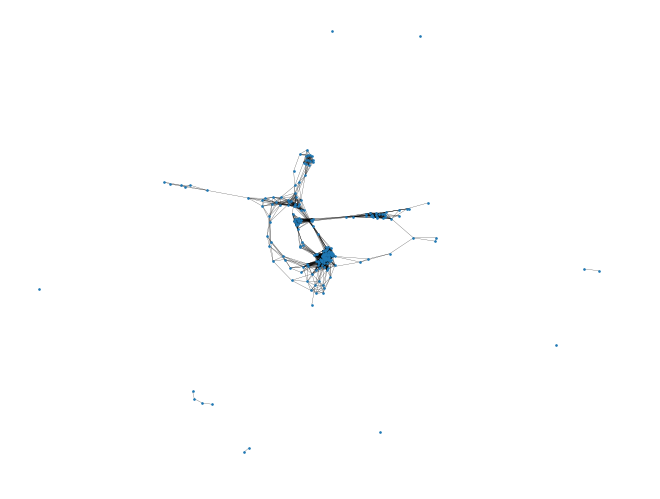

In [12]:
nx.draw_spring(G, node_size=0.8, width=0.15)
plt.show()

Computing degree centrality, betweenness centrality, closeness centrality and eigenvector centrality 

In [13]:
dc = nx.degree_centrality(G)
bc = nx.betweenness_centrality(G)
cc = nx.closeness_centrality(G)
ec = nx.eigenvector_centrality(G)

print(dc)
print(bc)
print(cc)
print(ec)

{'ahven': 0.07655502392344497, 'ananassalsa': 0.20095693779904306, 'anjovis': 0.0, 'ankerias': 0.06220095693779904, 'appelsiinimarmeladi': 0.06698564593301436, 'appelsiiniriisi': 0.20095693779904306, 'auringonkukkaöljy': 0.028708133971291863, 'avokadopasta': 0.1291866028708134, 'avokadoöljy': 0.06220095693779904, 'bambunverso': 0.09569377990430622, 'bearnaisekastike': 0.06220095693779904, 'broilerikeitto': 0.2583732057416268, 'broilerisuikale': 0.08133971291866028, 'chiansiemen': 0.014354066985645932, 'etana': 0.009569377990430622, 'etikkapunajuuri': 0.2822966507177033, 'etikkasienisäilyke': 0.03349282296650718, 'guava': 0.03349282296650718, 'haaparousku': 0.19617224880382775, 'hapankaali': 0.29186602870813394, 'hapankorppu': 0.028708133971291863, 'hauki': 0.07177033492822966, 'herkkusieni': 0.20095693779904306, 'herkkusienikeitto': 0.28708133971291866, 'herkkutatti': 0.19138755980861244, 'herneenverso': 0.014354066985645932, 'hillosipulisäilyke': 0.2727272727272727, 'hummeri': 0.07177

Identifying most influential food items

In [14]:
top_20_dc = sorted(dc.items(), key=lambda x: x[1], reverse=True)[:20]
top_20_bc = sorted(bc.items(), key=lambda x: x[1], reverse=True)[:20]
top_20_cc = sorted(cc.items(), key=lambda x: x[1], reverse=True)[:20]
top_20_ec = sorted(ec.items(), key=lambda x: x[1], reverse=True)[:20]

print("TOP 20 FOODS\n")
print(f"Highest degree centrality foods: {top_20_dc}\n")
print(f"Highest betweennes centrality foods: {top_20_bc}\n")
print(f"Highest closeness centrsality foods: {top_20_cc}\n")
print(f"Highest eigenvector centrlity foods: {top_20_ec}\n\n")

dc_names, dc_values = zip(*top_20_dc)   
bc_names, bc_values = zip(*top_20_bc)
cc_names, cc_values = zip(*top_20_cc)
ec_names, ec_values = zip(*top_20_ec)

print("TOP 3 FOODS FROM EACH MEASURE CATEGORY\n")
print(f"Top 3 foods with highest degree centrality: {dc_names[:3]}\n")
print(f"Top 3 foods with highest betweennes centrality: {bc_names[:3]}\n")
print(f"Top 3 foods with highest closeness centrality: {cc_names[:3]}\n")
print(f"Top 3 foods with highest eigenvector centrality: {ec_names[:3]}")


TOP 20 FOODS

Highest degree centrality foods: [('nauris', 0.3062200956937799), ('tomaatti', 0.3062200956937799), ('tomaattimurska', 0.3062200956937799), ('tomaattisalsa', 0.3062200956937799), ('kurkku', 0.30143540669856456), ('munakoiso', 0.30143540669856456), ('siskonmakkarakeitto', 0.2966507177033493), ('hapankaali', 0.29186602870813394), ('pinaattikeitto', 0.29186602870813394), ('siitakesieni', 0.29186602870813394), ('herkkusienikeitto', 0.28708133971291866), ('kesäkeitto', 0.28708133971291866), ('kukkakaalimuhennos', 0.28708133971291866), ('kurpitsa', 0.28708133971291866), ('vadelma', 0.28708133971291866), ('etikkapunajuuri', 0.2822966507177033), ('karviainen', 0.2822966507177033), ('porkkanamuhennos', 0.2822966507177033), ('minestronekeitto', 0.27751196172248804), ('punikkitatti', 0.27751196172248804)]

Highest betweennes centrality foods: [('puolukkahillo', 0.21345487996076848), ('suppilovahvero', 0.12241977482646885), ('herneenverso', 0.10742383350343833), ('porokeitto', 0.1071

Community detection with Girvan Newman algorithm

In [19]:
from networkx.algorithms.community import girvan_newman
import itertools

k = 12

comp = girvan_newman(G)

partitions = list(itertools.takewhile(lambda c: len(c) <= k,comp))

for communities in partitions:
    
    communities = list(communities)

    print(f"\nPartition with {len(communities)} communities:\n")

    for i, c in enumerate(communities):
        print(f"Community {i+1}: {len(c)} foods")


Partition with 10 communities:

Community 1: 169 foods
Community 2: 1 foods
Community 3: 28 foods
Community 4: 2 foods
Community 5: 1 foods
Community 6: 2 foods
Community 7: 1 foods
Community 8: 4 foods
Community 9: 1 foods
Community 10: 1 foods

Partition with 11 communities:

Community 1: 119 foods
Community 2: 1 foods
Community 3: 50 foods
Community 4: 28 foods
Community 5: 2 foods
Community 6: 1 foods
Community 7: 2 foods
Community 8: 1 foods
Community 9: 4 foods
Community 10: 1 foods
Community 11: 1 foods

Partition with 12 communities:

Community 1: 17 foods
Community 2: 102 foods
Community 3: 1 foods
Community 4: 50 foods
Community 5: 28 foods
Community 6: 2 foods
Community 7: 1 foods
Community 8: 2 foods
Community 9: 1 foods
Community 10: 4 foods
Community 11: 1 foods
Community 12: 1 foods


Saving only the clear communities

In [25]:
partition_12 = list(partitions[2])

girvan_community_1 = partition_12[0]
girvan_community_2 = partition_12[1]
girvan_community_4 = partition_12[3]
girvan_community_5 = partition_12[4]

Community detection with Louvain algorithm

In [26]:
from networkx.algorithms.community import louvain_communities

communities = louvain_communities(G, seed=42)

print(f"Number of communities: {len(communities)}\n")

for i, c in enumerate(communities):
    print(f"Community {i+1}: {len(c)} foods")

Number of communities: 16

Community 1: 1 foods
Community 2: 48 foods
Community 3: 6 foods
Community 4: 44 foods
Community 5: 2 foods
Community 6: 1 foods
Community 7: 2 foods
Community 8: 1 foods
Community 9: 34 foods
Community 10: 25 foods
Community 11: 4 foods
Community 12: 17 foods
Community 13: 6 foods
Community 14: 1 foods
Community 15: 1 foods
Community 16: 17 foods


Saving only the clear communities

In [27]:
louvain_community_2 = communities[1]
louvain_community_4 = communities[3]
louvain_community_9 = communities[8]
louvain_community_10 = communities[9]
louvain_community_12 = communities[11]
louvain_community_16 = communities[15]

Visualizing the Girvan Newman communities

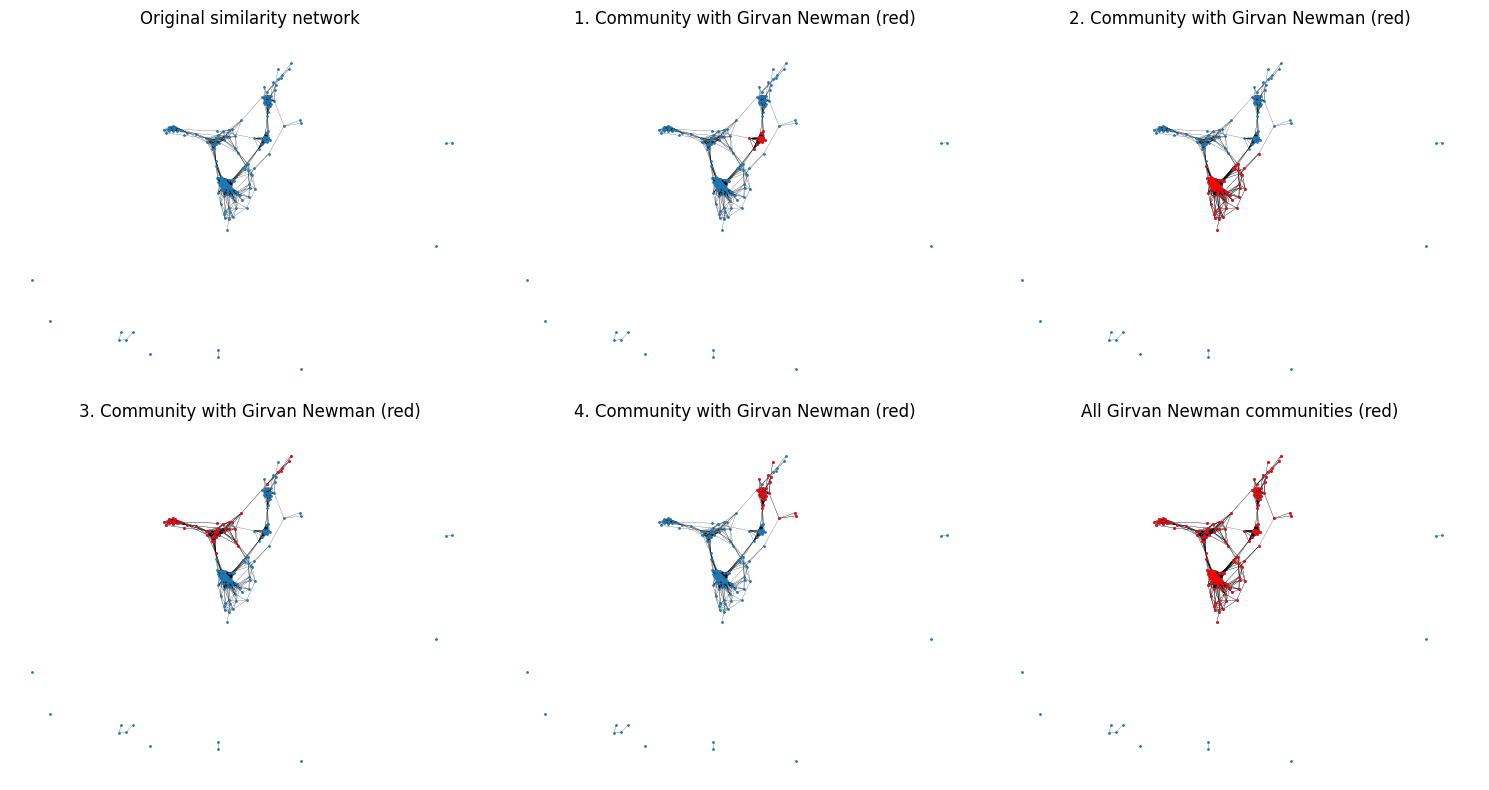

In [35]:
plt.figure(figsize=(15,8))

pos = nx.spring_layout(G)

plt.subplot(2,3,1)
plt.title("Original similarity network")
nx.draw(G, pos, node_size=1, width=0.15)

plt.subplot(2,3,2)
plt.title("1. Community with Girvan Newman (red)")
nx.draw(G, pos, node_size=1, width=0.15)
nx.draw(G.subgraph(girvan_community_1), pos, node_size=1, width=0.15, node_color="red")

plt.subplot(2,3,3)
plt.title("2. Community with Girvan Newman (red)")
nx.draw(G, pos, node_size=1, width=0.15)
nx.draw(G.subgraph(girvan_community_2), pos, node_size=1, width=0.15, node_color="red")

plt.subplot(2,3,4)
plt.title("3. Community with Girvan Newman (red)")
nx.draw(G, pos, node_size=1, width=0.15)
nx.draw(G.subgraph(girvan_community_4), pos, node_size=1, width=0.15, node_color="red")

plt.subplot(2,3,5)
plt.title("4. Community with Girvan Newman (red)")
nx.draw(G, pos, node_size=1, width=0.15)
nx.draw(G.subgraph(girvan_community_5), pos, node_size=1, width=0.15, node_color="red")

plt.subplot(2,3,6)
plt.title("All Girvan Newman communities (red)")
nx.draw(G, pos, node_size=1, width=0.15)
nx.draw(G.subgraph(girvan_community_1), pos, node_size=1, width=0.15, node_color="red")
nx.draw(G.subgraph(girvan_community_2), pos, node_size=1, width=0.15, node_color="red")
nx.draw(G.subgraph(girvan_community_4), pos, node_size=1, width=0.15, node_color="red")
nx.draw(G.subgraph(girvan_community_5), pos, node_size=1, width=0.15, node_color="red")


plt.tight_layout()
plt.show()

What foods occur in the Girvan Newman communities

In [30]:
for i, community in enumerate([
    girvan_community_1,
    girvan_community_2,
    girvan_community_4,
    girvan_community_5
]):
    
    print(f"\nCOMMUNITY {i+1}")
    print(sorted(list(community)))


COMMUNITY 1
['ahven', 'ankerias', 'kirjolohifilee', 'kuha', 'lahna', 'lipeäkala', 'lohifilee', 'siika', 'silakkafilee', 'silakkahyytelö', 'suppilovahvero', 'särki', 'taimen', 'tomaattisilakka', 'tonnikala', 'turska', 'uunikala']

COMMUNITY 2
['ananassalsa', 'appelsiiniriisi', 'avokadopasta', 'bambunverso', 'broilerikeitto', 'etikkapunajuuri', 'etikkasienisäilyke', 'guava', 'haaparousku', 'hapankaali', 'herkkusieni', 'herkkusienikeitto', 'herkkutatti', 'herneenverso', 'hillosipulisäilyke', 'italianpata', 'juolukka', 'jääsalaatti', 'kangasrousku', 'kantarelli', 'karpalo', 'karvarousku', 'karviainen', 'kastanja', 'kesäkeitto', 'ketsuppi', 'kiinankaali', 'kinkkupasta', 'korvasieni', 'kukkakaali', 'kukkakaalimuhennos', 'kurkku', 'kurpitsa', 'lanttu', 'latva-artisokka', 'lehtikaali', 'lehtikaalisipsit', 'linssikeitto', 'lohkoperuna', 'maa-artisokka', 'makkarakeitto', 'mangoldi', 'mansikka', 'minestronekeitto', 'munakoiso', 'munatoti', 'mustaherukka', 'mustajuuri', 'mämmi', 'nakkikeitto', 'n

Visualizing the Louvain communities

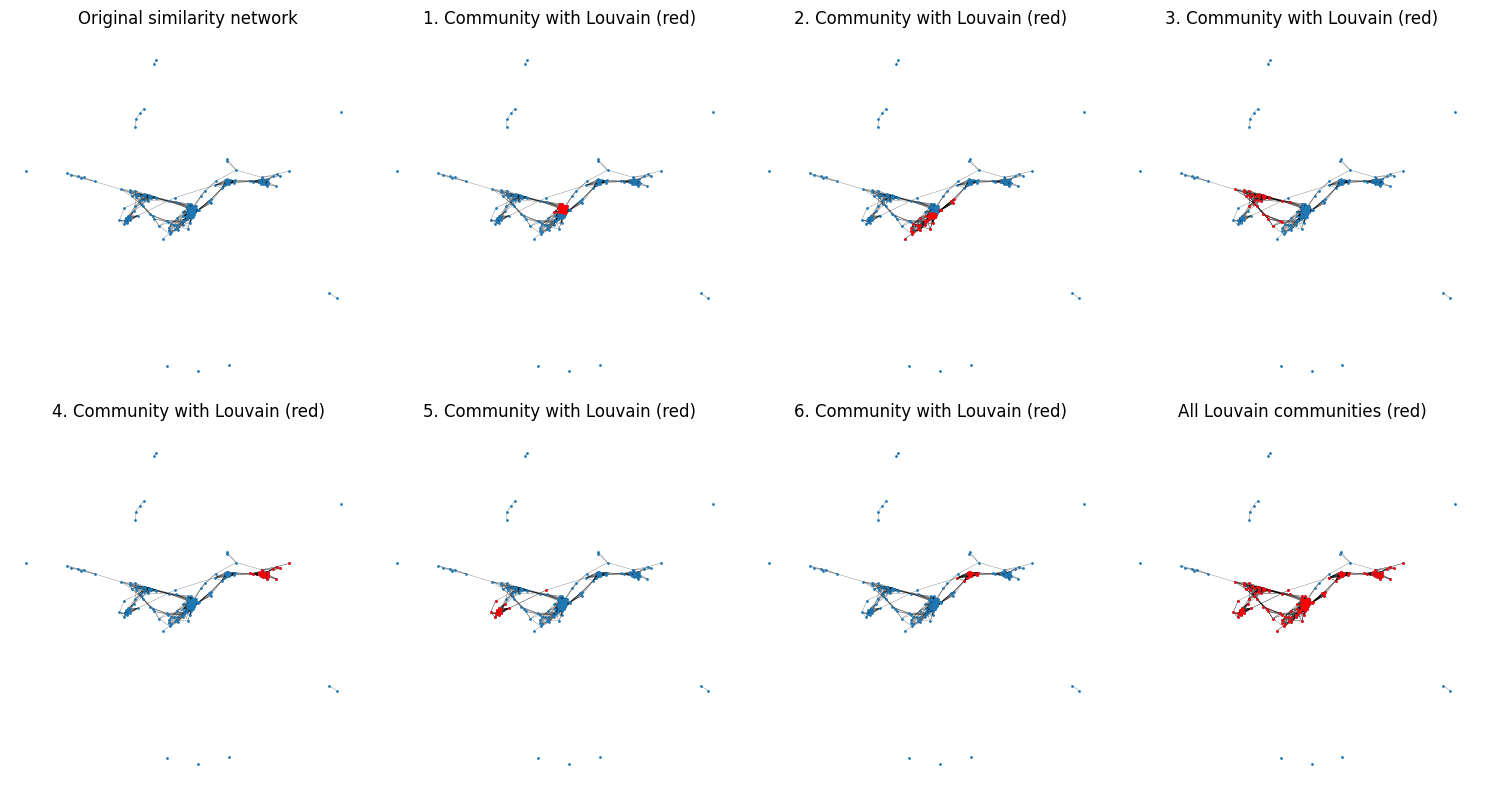

In [33]:
plt.figure(figsize=(15,8))

pos = nx.spring_layout(G)

plt.subplot(2,4,1)
plt.title("Original similarity network")
nx.draw(G, pos, node_size=1, width=0.15)

plt.subplot(2,4,2)
plt.title("1. Community with Louvain (red)")
nx.draw(G, pos, node_size=1, width=0.15)
nx.draw(G.subgraph(louvain_community_2), pos, node_size=1, width=0.15, node_color="red")

plt.subplot(2,4,3)
plt.title("2. Community with Louvain (red)")
nx.draw(G, pos, node_size=1, width=0.15)
nx.draw(G.subgraph(louvain_community_4), pos, node_size=1, width=0.15, node_color="red")

plt.subplot(2,4,4)
plt.title("3. Community with Louvain (red)")
nx.draw(G, pos, node_size=1, width=0.15)
nx.draw(G.subgraph(louvain_community_9), pos, node_size=1, width=0.15, node_color="red")

plt.subplot(2,4,5)
plt.title("4. Community with Louvain (red)")
nx.draw(G, pos, node_size=1, width=0.15)
nx.draw(G.subgraph(louvain_community_10), pos, node_size=1, width=0.15, node_color="red")

plt.subplot(2,4,6)
plt.title("5. Community with Louvain (red)")
nx.draw(G, pos, node_size=1, width=0.15)
nx.draw(G.subgraph(louvain_community_12), pos, node_size=1, width=0.15, node_color="red")

plt.subplot(2,4,7)
plt.title("6. Community with Louvain (red)")
nx.draw(G, pos, node_size=1, width=0.15)
nx.draw(G.subgraph(louvain_community_16), pos, node_size=1, width=0.15, node_color="red")

plt.subplot(2,4,8)
plt.title("All Louvain communities (red)")
nx.draw(G, pos, node_size=1, width=0.15)
nx.draw(G.subgraph(louvain_community_2), pos, node_size=1, width=0.15, node_color="red")
nx.draw(G.subgraph(louvain_community_4), pos, node_size=1, width=0.15, node_color="red")
nx.draw(G.subgraph(louvain_community_9), pos, node_size=1, width=0.15, node_color="red")
nx.draw(G.subgraph(louvain_community_10), pos, node_size=1, width=0.15, node_color="red")
nx.draw(G.subgraph(louvain_community_12), pos, node_size=1, width=0.15, node_color="red")
nx.draw(G.subgraph(louvain_community_16), pos, node_size=1, width=0.15, node_color="red")


plt.tight_layout()
plt.show()

What foods occur in Louvain communities

In [36]:
for i, community in enumerate([
    louvain_community_2,
    louvain_community_4,
    louvain_community_9,
    louvain_community_10,
    louvain_community_12,
    louvain_community_16
]):
    
    print(f"\nCOMMUNITY {i+1}")
    print(sorted(list(community)))


COMMUNITY 1
['ananassalsa', 'appelsiiniriisi', 'avokadopasta', 'broilerikeitto', 'etikkapunajuuri', 'hapankaali', 'herkkusienikeitto', 'hillosipulisäilyke', 'italianpata', 'juolukka', 'karpalo', 'karviainen', 'kesäkeitto', 'kinkkupasta', 'kurkku', 'kurpitsa', 'linssikeitto', 'makkarakeitto', 'mansikka', 'minestronekeitto', 'munakoiso', 'munatoti', 'nakkikeitto', 'nauris', 'pinaattikeitto', 'porkkanamuhennos', 'punaviini', 'punaviinikastike', 'punikkitatti', 'puolukka', 'rahkajuoma', 'savuporokeitto', 'siitakesieni', 'sima', 'sipulikeitto', 'siskonmakkarakeitto', 'ternimaito', 'tomaatti', 'tomaattikastike', 'tomaattikeitto', 'tomaattimurska', 'tomaattisalsa', 'uuniomena', 'vadelma', 'vihanneskrassi', 'viinietikka', 'virvoitusjuoma', 'väkiviinaetikka']

COMMUNITY 2
['bambunverso', 'etikkasienisäilyke', 'guava', 'haaparousku', 'herkkusieni', 'herkkutatti', 'jääsalaatti', 'kangasrousku', 'kantarelli', 'karvarousku', 'ketsuppi', 'kiinankaali', 'korvasieni', 'kukkakaali', 'kukkakaalimuhenno